# **1. Instalação das dependências de Linguagem**

In [ ]:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 48.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# **2. Importação das Bibliotecas**

In [ ]:
import pandas as pd
import spacy
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar o modelo de NLP em português
nlp = spacy.load("pt_core_news_sm")


# **3. Carregamento e divisão das Cargas de Treino e Teste Separadas**

In [ ]:
# Carregar o dataset
df = pd.read_csv('/content/dataset_emails_expandido.csv', on_bad_lines='skip',
                 engine='python')

# Limpeza preventiva: remover linhas sem label e garantir que são números inteiros
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Divisão Automática em Treino e Teste (50/50)
df_treino, df_teste = train_test_split(df, test_size=0.5, random_state=42,
                                       stratify=df['label'])

# Criar cópias independentes para evitar avisos do Pandas no processamento
df_treino = df_treino.copy()
df_teste = df_teste.copy()

print(f"Carga de Treino: {df_treino.shape[0]} registros.")
print(f"Carga de Teste: {df_teste.shape[0]} registros.")


Carga de Treino: 50 registros.
Carga de Teste: 50 registros.


# **4. Pré-processamento de Dados (1º passo)**

In [ ]:
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    doc = nlp(texto)
    tokens_limpos = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.is_space]
    return " ".join(tokens_limpos)

# Juntar assunto e corpo, protegendo contra valores nulos
df_treino['texto_completo'] = df_treino['subject'].fillna('') + " " + df_treino['body'].fillna('')
df_teste['texto_completo'] = df_teste['subject'].fillna('') + " " + df_teste['body'].fillna('')

print("Realizando a limpeza de texto e lematização...")
df_treino['texto_limpo'] = df_treino['texto_completo'].apply(limpar_texto)
df_teste['texto_limpo'] = df_teste['texto_completo'].apply(limpar_texto)
print("Limpeza concluída!")


Realizando a limpeza de texto e lematização...
Limpeza concluída!


# **5. Vetorização com TF-IDF**

In [ ]:
tfidf = TfidfVectorizer(max_features=500)

X_treino = tfidf.fit_transform(df_treino['texto_limpo'])
y_treino = df_treino['label']

X_teste = tfidf.transform(df_teste['texto_limpo'])
y_teste = df_teste['label']

print(f"Dimensões da matriz de treino: {X_treino.shape}")
print(f"Dimensões da matriz de teste: {X_teste.shape}")


Dimensões da matriz de treino: (50, 118)
Dimensões da matriz de teste: (50, 118)


# **6. Desenvolvimento do Modelo (2º Objetivo)**

In [ ]:
# Inicializar e treinar o algoritmo de classificação
modelo_nb = MultinomialNB()
modelo_nb.fit(X_treino, y_treino)

# Fazer previsões usando unicamente a carga de teste invisível
previsoes = modelo_nb.predict(X_teste)
print("Modelo treinado e previsões realizadas com sucesso.")

Modelo treinado e previsões realizadas com sucesso.


# **7. Avaliação e Matriz de Confusão**

--- RESULTADOS DA AVALIAÇÃO ---
Acurácia: 0.96 (Percentual de previsões corretas feitas pelo modelo)
Precisão: 0.92 (Proporção de verdadeiros positivos entre as previsões positivas)
Recall:   1.00 (Proporção de verdadeiros positivos entre todos os casos positivos)
F1-Score: 0.96 (Média harmônica entre precisão e recall)



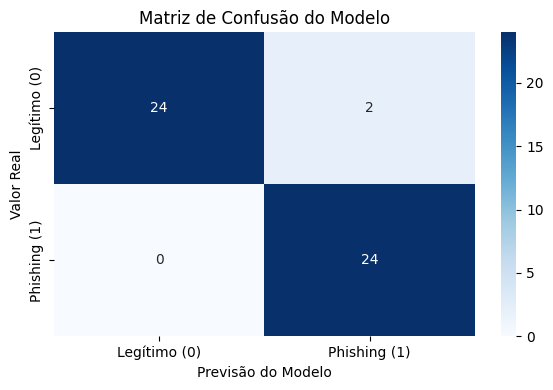

In [ ]:
acuracia = accuracy_score(y_teste, previsoes)
precisao = precision_score(y_teste, previsoes, zero_division=0)
recall = recall_score(y_teste, previsoes, zero_division=0)
f1 = f1_score(y_teste, previsoes, zero_division=0)

print("--- RESULTADOS DA AVALIAÇÃO ---")
print(f"Acurácia: {acuracia:.2f} (Percentual de previsões corretas feitas pelo modelo)")
print(f"Precisão: {precisao:.2f} (Proporção de verdadeiros positivos entre as previsões positivas)")
print(f"Recall:   {recall:.2f} (Proporção de verdadeiros positivos entre todos os casos positivos)")
print(f"F1-Score: {f1:.2f} (Média harmônica entre precisão e recall)\n")

# Visualizar Matriz de Confusão
matriz = confusion_matrix(y_teste, previsoes)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo (0)', 'Phishing (1)'],
            yticklabels=['Legítimo (0)', 'Phishing (1)'])
plt.title('Matriz de Confusão do Modelo')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()
